In [43]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

# models = list_models('vllm') + ['siglip2_so400_16_512']
models = list_models('vllm') + ['siglip2_so400_16_256']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("num_classes")
results["num_classes"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['model_name'].str.contains('SigLIP')) | (results['task_name'] == 'multi_choice_relation')]

File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

/tmp/ipykernel_1965082/3377660876.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1965082/3377660876.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=90, ha='right')
/tmp/ipykernel_1965082/3377660876.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1965082/3377660876.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=90, ha='right')
/tmp/ipykernel_1965082/3377660876.py:39: FutureWarning: 

Passing 

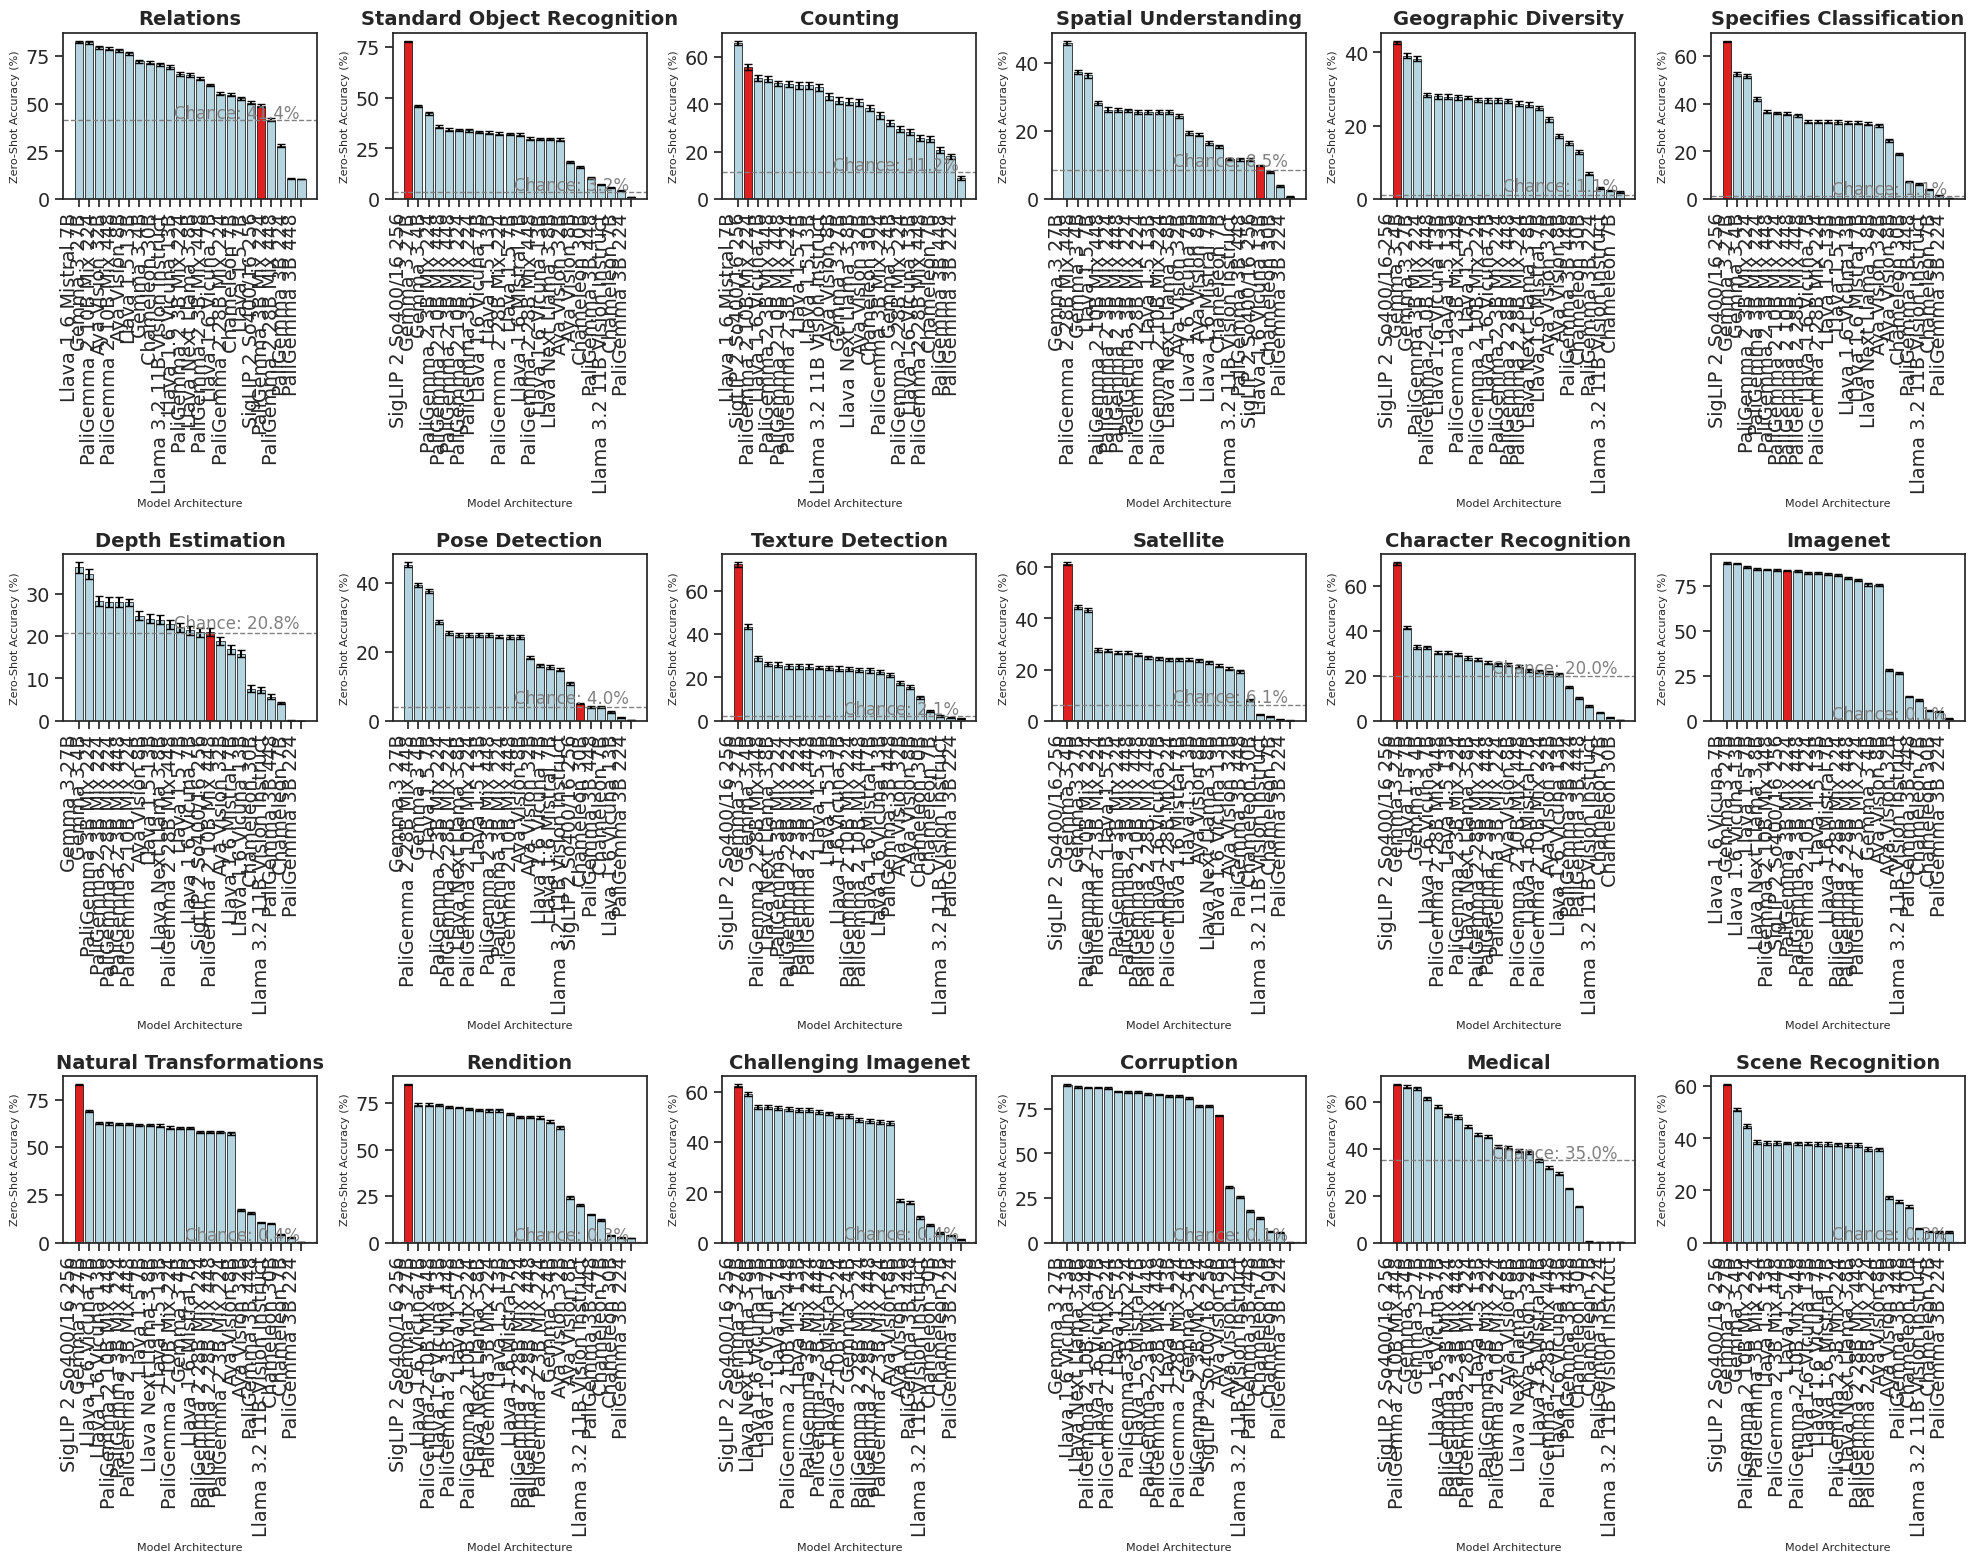

In [44]:
# --- Styling ---
LABEL_FONT_SIZE = 8
TICK_FONT_SIZE = 12
TITLE_FONT_SIZE = 14
ANNOTATION_FONT_SIZE = 12

# Get unique benchmark types
benchmark_types = results['capability'].unique()

# Create subplots
fig, axes = plt.subplots(4, 6, figsize=(20, 18))
axes = axes.flatten()

for i, bench_type in enumerate(benchmark_types):
    # Filter data for this benchmark type
    type_results = results[results['capability'] == bench_type]
    
    # Compute average and SEM for this benchmark type
    df_mean_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.mean()
    df_sem_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.sem()
    
    type_performance = df_mean_type.reset_index().groupby("model_name").correctness.mean() * 100
    type_sem = df_sem_type.reset_index().groupby("model_name").correctness.mean() * 100
    
    type_model_data = pd.DataFrame({
        'model_name': type_performance.index,
        'performance': type_performance.values,
        'sem': type_sem.values
    })
    
    # Sort by performance
    sorted_type_models = type_model_data.sort_values('performance', ascending=False)
    
    # Create colors: red for SigLIP, light blue for others
    colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_type_models['model_name']]
    
    # Create barplot for this subplot
    ax = axes[i]
    sns.barplot(
        data=sorted_type_models,
        x='model_name',
        y='performance',
        palette=colors,
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    # Add error bars
    for j, row in enumerate(sorted_type_models.itertuples()):
        ax.errorbar(j, row.performance, yerr=row.sem, fmt='none', color='black',
                   capsize=3, elinewidth=1.5)
    
    # Customize this subplot
    ax.set_xlabel('Model Architecture', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=LABEL_FONT_SIZE)
    ax.set_title(f'{bench_type.title()}', fontsize=TITLE_FONT_SIZE, weight='bold')
    
    # Format x-axis labels
    tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_type_models['model_name']]
    ax.set_xticklabels(tick_labels, rotation=90, ha='right')
    
    # Compute chance level as average (1/num_classes) across benchmarks within this capability
    capability_benchmarks = type_results['benchmark_name'].unique()
    chance_levels = []
    for benchmark in capability_benchmarks:
        num_classes = benchmark_mappings[benchmark]
        chance_levels.append((1/num_classes) * 100)
    chance_level = sum(chance_levels) / len(chance_levels)
    
    # Add chance level line
    ax.axhline(chance_level, linestyle='--', color='gray', linewidth=1)
    ax.text(len(sorted_type_models) - 1.2, chance_level + 1,
            f'Chance: {chance_level:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
            color='gray', ha='right')

# Hide any unused subplots
for i in range(len(benchmark_types), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1965082/1435977497.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([label.get_text().title() for label in ax1.get_xticklabels()])
/tmp/ipykernel_1965082/1435977497.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()])


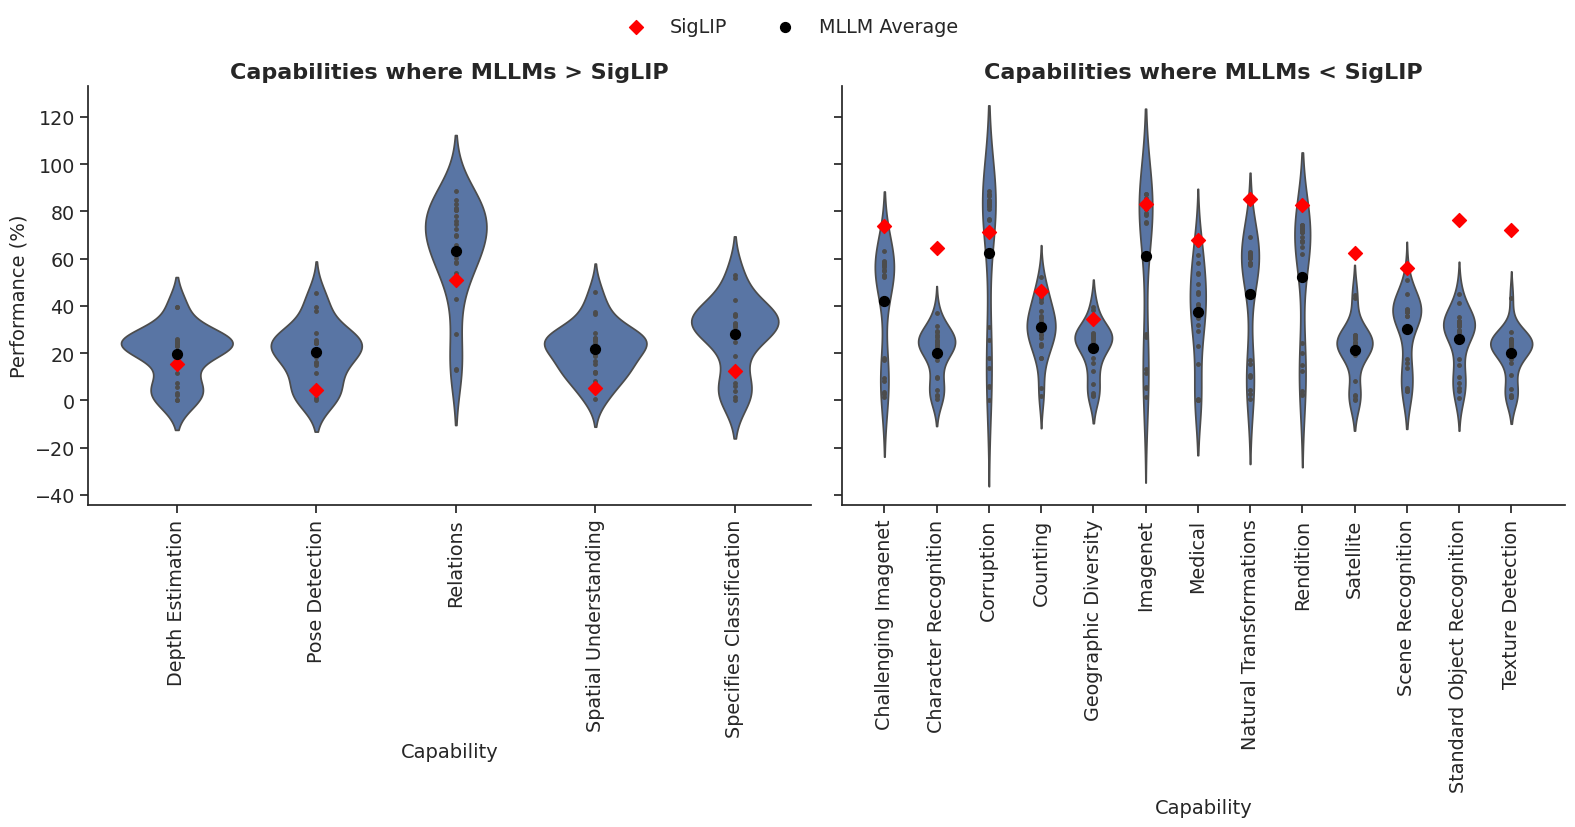

Capabilities where MLLMs outperform SigLIP: ['depth estimation', 'pose detection', 'relations', 'spatial understanding', 'specifies classification']
Capabilities where MLLMs underperform SigLIP: ['challenging imagenet', 'character recognition', 'corruption', 'counting', 'geographic diversity', 'imagenet', 'medical', 'natural transformations', 'rendition', 'satellite', 'scene recognition', 'standard object recognition', 'texture detection']


In [23]:
sns.set_theme(style="ticks", font_scale=1.25)
# Get SigLIP performance for each capability
siglip_performance = results[results['model_name'] == 'SigLIP 2 So400/16 256'].groupby('capability').correctness.mean() * 100

# Get average MLLM performance for each capability (excluding SigLIP)
mllm_results = results[results['model_name'] != 'SigLIP 2 So400/16 256']
mllm_performance = mllm_results.groupby('capability').correctness.mean() * 100

# Identify capabilities where MLLMs outperform or underperform SigLIP
outperform_capabilities = []
underperform_capabilities = []

for capability in siglip_performance.index:
    if capability in mllm_performance.index:
        if mllm_performance[capability] > siglip_performance[capability]:
            outperform_capabilities.append(capability)
        else:
            underperform_capabilities.append(capability)

# Prepare data for violin plots
outperform_data = []
underperform_data = []

for capability in outperform_capabilities:
    cap_data = mllm_results[mllm_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        outperform_data.append({'capability': capability, 'performance': perf})

for capability in underperform_capabilities:
    cap_data = mllm_results[mllm_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        underperform_data.append({'capability': capability, 'performance': perf})

outperform_df = pd.DataFrame(outperform_data)
underperform_df = pd.DataFrame(underperform_data)

# Create violin plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Plot 1: Capabilities where MLLMs outperform SigLIP
if not outperform_df.empty:
    sns.violinplot(data=outperform_df, x='capability', y='performance', ax=ax1, inner="point")
    ax1.set_title('Capabilities where MLLMs > SigLIP', fontsize=TITLE_FONT_SIZE, weight='bold')
    ax1.set_xlabel('Capability', fontsize=LABEL_FONT_SIZE)
    ax1.set_ylabel('Performance (%)', fontsize=LABEL_FONT_SIZE)
    ax1.tick_params(axis='x', rotation=90)
    
    # Capitalize x-axis labels
    ax1.set_xticklabels([label.get_text().title() for label in ax1.get_xticklabels()])

    # Add SigLIP reference points
    for capability in outperform_capabilities:
        if capability in siglip_performance.index:
            cap_idx = list(outperform_df['capability'].unique()).index(capability)
            ax1.scatter(cap_idx, siglip_performance[capability], color='red', s=50, marker='D', zorder=10, label='SigLIP' if cap_idx == 0 else "")
            # Add average MLLM performance as black point
            avg_mllm = mllm_performance[capability]
            ax1.scatter(cap_idx, avg_mllm, color='black', s=50, marker='o', zorder=10, label='MLLM Average' if cap_idx == 0 else "")

# Plot 2: Capabilities where MLLMs underperform SigLIP
if not underperform_df.empty:
    sns.violinplot(data=underperform_df, x='capability', y='performance', ax=ax2, inner="point")
    ax2.set_title('Capabilities where MLLMs < SigLIP', fontsize=TITLE_FONT_SIZE, weight='bold')
    ax2.set_xlabel('Capability', fontsize=LABEL_FONT_SIZE)
    ax2.set_ylabel('Performance (%)', fontsize=LABEL_FONT_SIZE)
    ax2.tick_params(axis='x', rotation=90)

    # Capitalize x-axis labels
    ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()])

    # Add SigLIP reference points
    for capability in underperform_capabilities:
        if capability in siglip_performance.index:
            cap_idx = list(underperform_df['capability'].unique()).index(capability)
            ax2.scatter(cap_idx, siglip_performance[capability], color='red', s=50, marker='D', zorder=10, label='SigLIP' if cap_idx == 0 else "")
            # Add average MLLM performance as black point
            avg_mllm = mllm_performance[capability]
            ax2.scatter(cap_idx, avg_mllm, color='black', s=50, marker='o', zorder=10, label='MLLM Average' if cap_idx == 0 else "")

# Add a single legend at the top of the figure
handles, labels = [], []
if not outperform_df.empty:
    h, l = ax1.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
if not underperform_df.empty:
    h, l = ax2.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

# Add the legend at the top of the figure
if handles:
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(labels), frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Capabilities where MLLMs outperform SigLIP: {outperform_capabilities}")
print(f"Capabilities where MLLMs underperform SigLIP: {underperform_capabilities}")


In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

# models = list_models('vllm') + ['siglip2_so400_16_512']
models = list_models('vllm') + ['siglip2_so400_16_256', 'clip_vitL14', 'eva01_vitG14_plus_2b' , 'siglip2_so400_16_384', 'siglip2_so400_16_512', 'eva01_vitG14_400m']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("num_classes")
results["num_classes"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['model_name'].str.contains('CLIP')) | (results['model_name'].str.contains('EVA')) | (results['model_name'].str.contains('SigLIP')) | (results['task_name'] == 'multi_choice_relation')]

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

In [4]:
results.capability.unique()

array(['relations', 'standard object recognition', 'counting',
       'spatial understanding', 'geographic diversity',
       'specifies classification', 'depth estimation', 'pose detection',
       'texture detection', 'satellite', 'character recognition',
       'imagenet', 'natural transformations', 'rendition',
       'challenging imagenet', 'corruption', 'medical',
       'scene recognition'], dtype=object)

/tmp/ipykernel_961540/1113805221.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([label.get_text().title() for label in ax1.get_xticklabels()], fontsize=12, ha='right')
/tmp/ipykernel_961540/1113805221.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()], fontsize=12, ha='right')


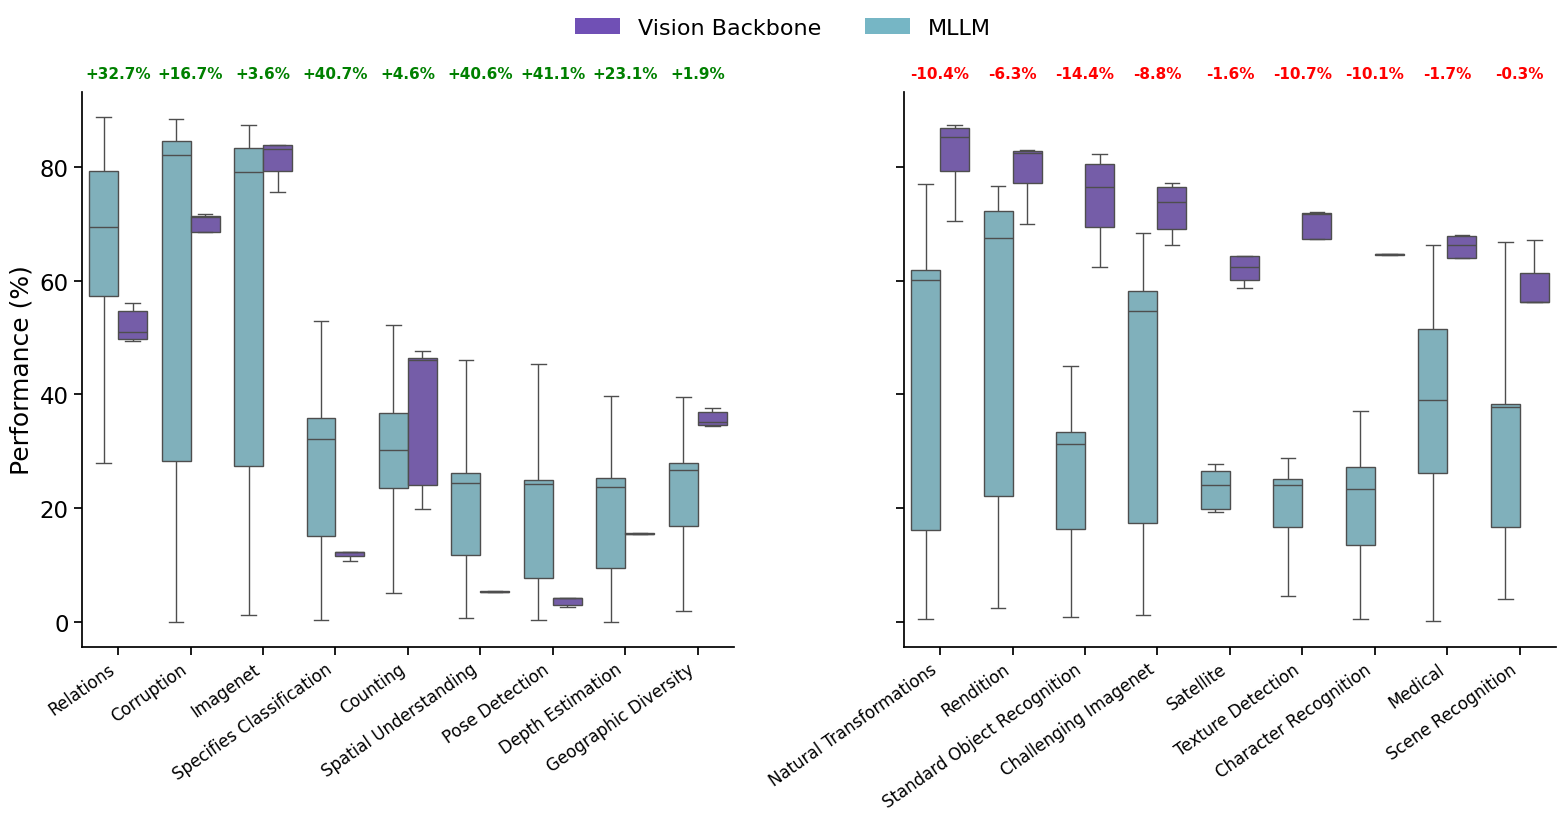

Capabilities where best MLLMs outperform best Vision Backbones: ['relations', 'corruption', 'imagenet', 'specifies classification', 'counting', 'spatial understanding', 'pose detection', 'depth estimation', 'geographic diversity']
Capabilities where best MLLMs underperform best Vision Backbones: ['natural transformations', 'rendition', 'standard object recognition', 'challenging imagenet', 'satellite', 'texture detection', 'character recognition', 'medical', 'scene recognition']


In [18]:
sns.set_context("notebook", font_scale=1.5)

# Get all models and identify vision backbone models
vision_backbone_models = ['SigLIP 2 So400/16 256', 'CLIP ViT-L/14', 'EVA01 ViT-g/14 Plus', 
                         'SigLIP 2 So400/16 384', 'SigLIP 2 So400/16 512', 'EVA01 ViT-g/14 400M']

# Add model_type column to results dataframe
results['model_type'] = results['model_name'].apply(lambda x: 'Vision Backbone' if x in vision_backbone_models else 'MLLM')

# Filter data for vision backbone and MLLM models
vision_backbone_results = results[results['model_name'].isin(vision_backbone_models)]
mllm_results = results[~results['model_name'].isin(vision_backbone_models)]

# Calculate performance for each model and capability
capability_performance = results.groupby(['capability', 'model_type', 'model_name']).correctness.mean().reset_index()
capability_performance['performance'] = capability_performance['correctness'] * 100

# Get best performance for each capability and model type
best_performance_by_type = capability_performance.groupby(['capability', 'model_type']).performance.max().reset_index()

# Get best MLLM and Vision Backbone performance for each capability
best_mllm_performance = best_performance_by_type[best_performance_by_type['model_type'] == 'MLLM'].set_index('capability')['performance']
best_vision_backbone_performance = best_performance_by_type[best_performance_by_type['model_type'] == 'Vision Backbone'].set_index('capability')['performance']

# Identify capabilities where MLLMs outperform or underperform Vision Backbones
outperform_capabilities = []
underperform_capabilities = []

for capability in best_mllm_performance.index:
    if capability in best_vision_backbone_performance.index:
        if best_mllm_performance[capability] > best_vision_backbone_performance[capability]:
            outperform_capabilities.append(capability)
        else:
            underperform_capabilities.append(capability)

# Sort capabilities by best MLLM performance (descending)
outperform_capabilities_sorted = sorted(outperform_capabilities, key=lambda x: best_mllm_performance[x], reverse=True)
underperform_capabilities_sorted = sorted(underperform_capabilities, key=lambda x: best_vision_backbone_performance[x], reverse=True)

# Prepare data for box plots
outperform_data = []
underperform_data = []

for capability in outperform_capabilities_sorted:
    # Add MLLM data
    cap_data = mllm_results[mllm_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        outperform_data.append({'capability': capability, 'performance': perf, 'model_type': 'MLLM'})
    
    # Add Vision Backbone data
    cap_data = vision_backbone_results[vision_backbone_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        outperform_data.append({'capability': capability, 'performance': perf, 'model_type': 'Vision Backbone'})

for capability in underperform_capabilities_sorted:
    # Add MLLM data
    cap_data = mllm_results[mllm_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        underperform_data.append({'capability': capability, 'performance': perf, 'model_type': 'MLLM'})
    
    # Add Vision Backbone data
    cap_data = vision_backbone_results[vision_backbone_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        underperform_data.append({'capability': capability, 'performance': perf, 'model_type': 'Vision Backbone'})

outperform_data = pd.DataFrame(outperform_data)
underperform_data = pd.DataFrame(underperform_data)

# Calculate performance differences for annotations
performance_differences = {}

for capability in outperform_capabilities_sorted:
    best_mllm = best_mllm_performance[capability]
    best_vb = best_vision_backbone_performance[capability]
    diff = best_mllm - best_vb
    performance_differences[capability] = diff

for capability in underperform_capabilities_sorted:
    best_mllm = best_mllm_performance[capability]
    best_vb = best_vision_backbone_performance[capability]
    diff = best_mllm - best_vb
    performance_differences[capability] = diff

# Create box plots with difference annotations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Define colors for model types
palette = {'Vision Backbone': '#7050b5', 'MLLM': '#76b6c5'}

# Plot 1: Capabilities where best MLLMs outperform best Vision Backbones
if not outperform_data.empty:
    sns.boxplot(data=outperform_data, x='capability', y='performance', hue='model_type',
                ax=ax1, palette=palette, order=outperform_capabilities_sorted, showfliers=False)
    # ax1.set_xlabel('Capability')
    ax1.set_xlabel(None)
    ax1.set_ylabel('Performance (%)')
    ax1.tick_params(axis='x', rotation=35)
    
    # Capitalize x-axis labels
    ax1.set_xticklabels([label.get_text().title() for label in ax1.get_xticklabels()], fontsize=12, ha='right')
    
    for i, capability in enumerate(outperform_capabilities_sorted):
        diff = performance_differences[capability]
        xpos = ax1.get_xticks()[i]  # correct tick position
        ax1.text(xpos, ax1.get_ylim()[1] * 1.02, f'+{diff:.1f}%', 
                ha='center', va='bottom', fontweight='bold', color='green', fontsize=11)
    # Adjust x-axis label positions to the left slightly
    labels = ax1.get_xticklabels()
    for label in labels:
        label.set_horizontalalignment('right')
        label.set_x(label.get_position()[0] - 0.1)
    
    
    # Add difference annotations above each box plot with smaller font
    # for i, capability in enumerate(outperform_capabilities_sorted):
    #     diff = performance_differences[capability]
    #     ax1.text(i, ax1.get_ylim()[1] * 1, f'+{diff:.1f}%', 
    #             ha='center', va='bottom', fontweight='bold', color='green', fontsize=11)
    
    # Remove legend for this subplot
    ax1.get_legend().remove()

# Plot 2: Capabilities where best MLLMs underperform best Vision Backbones
if not underperform_data.empty:
    sns.boxplot(data=underperform_data, x='capability', y='performance', hue='model_type',
                ax=ax2, palette=palette, order=underperform_capabilities_sorted, showfliers=False)
    # ax2.set_xlabel('Capability')
    ax2.set_xlabel(None)
    ax2.set_ylabel('Performance (%)')
    ax2.tick_params(axis='x', rotation=35)

    # Capitalize x-axis labels and align by the right
    ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()], fontsize=12, ha='right')
    
    for i, capability in enumerate(underperform_capabilities_sorted):
        diff = performance_differences[capability]
        xpos = ax2.get_xticks()[i]  # correct tick position
        ax2.text(xpos, ax2.get_ylim()[1] * 1.02, f'{diff:.1f}%', 
                ha='center', va='bottom', fontweight='bold', color='red', fontsize=11)
    
    # # Add difference annotations above each box plot with smaller font
    # for i, capability in enumerate(underperform_capabilities_sorted):
    #     diff = performance_differences[capability]
    #     xpos = ax2.get_xticks()[i]  # correct tick position
    #     ax2.text(xpos, ax2.get_ylim()[1] * 1.02, f'{diff:.1f}%', 
    #             ha='center', va='bottom', fontweight='bold', color='red', fontsize=11)

    
    
    # Remove legend for this subplot
    ax2.get_legend().remove()

# Add a single legend at the top of the figure
handles = [plt.Rectangle((0,0),1,1, facecolor=palette['Vision Backbone'], label='Vision Backbone'),
           plt.Rectangle((0,0),1,1, facecolor=palette['MLLM'], label='MLLM')]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False, fontsize=16)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Capabilities where best MLLMs outperform best Vision Backbones: {outperform_capabilities_sorted}")
print(f"Capabilities where best MLLMs underperform best Vision Backbones: {underperform_capabilities_sorted}")


/tmp/ipykernel_88396/2917852879.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_mllm_performance = mllm_results.groupby('capability').apply(
/tmp/ipykernel_88396/2917852879.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([label.get_text().title() for label in ax1.get_xticklabels()])
/tmp/ipykernel_88396/2917852879.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()])


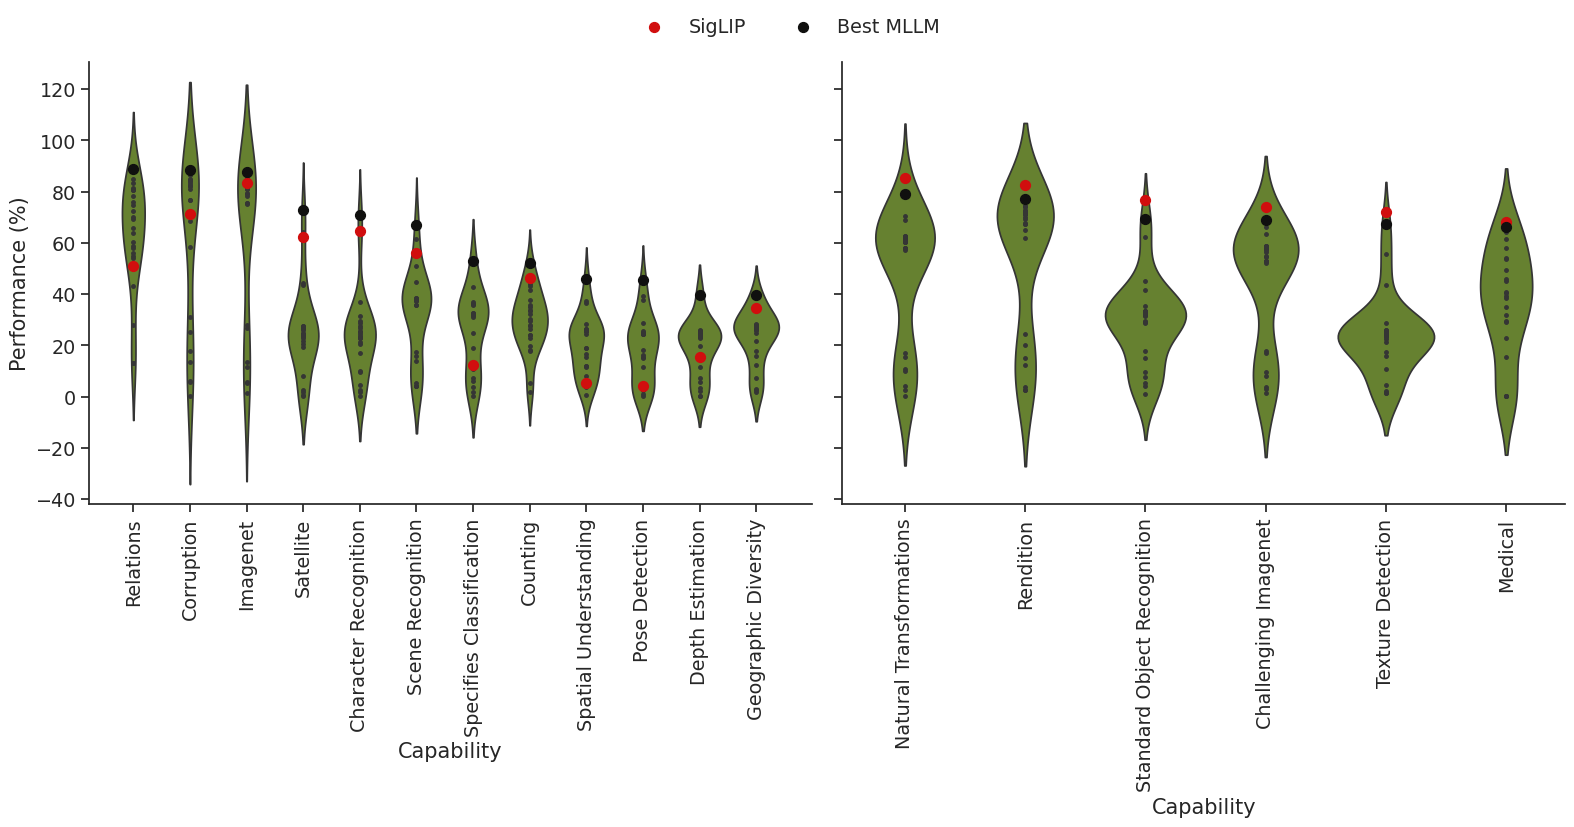

Capabilities where best MLLMs outperform SigLIP: ['relations', 'corruption', 'imagenet', 'satellite', 'character recognition', 'scene recognition', 'specifies classification', 'counting', 'spatial understanding', 'pose detection', 'depth estimation', 'geographic diversity']
Capabilities where best MLLMs underperform SigLIP: ['natural transformations', 'rendition', 'standard object recognition', 'challenging imagenet', 'texture detection', 'medical']


In [4]:
sns.set_theme(style="ticks", font_scale=1.25)
# Get SigLIP performance for each capability
siglip_performance = results[results['model_name'] == 'SigLIP 2 So400/16 256'].groupby('capability').correctness.mean() * 100

# Get best MLLM performance for each capability (excluding SigLIP)
mllm_results = results[results['model_name'] != 'SigLIP 2 So400/16 256']
best_mllm_performance = mllm_results.groupby('capability').apply(
    lambda x: x.groupby('model_name').correctness.mean().max()
) * 100

# Identify capabilities where best MLLMs outperform or underperform SigLIP
outperform_capabilities = []
underperform_capabilities = []

for capability in siglip_performance.index:
    if capability in best_mllm_performance.index:
        if best_mllm_performance[capability] > siglip_performance[capability]:
            outperform_capabilities.append(capability)
        else:
            underperform_capabilities.append(capability)

# Sort capabilities by best MLLM performance (descending)
outperform_capabilities_sorted = sorted(outperform_capabilities, key=lambda x: best_mllm_performance[x], reverse=True)
underperform_capabilities_sorted = sorted(underperform_capabilities, key=lambda x: siglip_performance[x], reverse=True)

# Prepare data for violin plots
outperform_data = []
underperform_data = []

for capability in outperform_capabilities_sorted:
    cap_data = mllm_results[mllm_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        outperform_data.append({'capability': capability, 'performance': perf})

for capability in underperform_capabilities_sorted:
    cap_data = mllm_results[mllm_results['capability'] == capability]
    cap_performance = cap_data.groupby('model_name').correctness.mean() * 100
    for perf in cap_performance:
        underperform_data.append({'capability': capability, 'performance': perf})

outperform_df = pd.DataFrame(outperform_data)
underperform_df = pd.DataFrame(underperform_data)

# Create violin plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Plot 1: Capabilities where best MLLMs outperform SigLIP
if not outperform_df.empty:
    sns.violinplot(data=outperform_df, x='capability', y='performance', ax=ax1, inner="point", color='#6B8E23', order=outperform_capabilities_sorted)
    # ax1.set_title('Capabilities where Best MLLMs > SigLIP', fontsize=TITLE_FONT_SIZE, weight='bold')
    ax1.set_xlabel('Capability')
    ax1.set_ylabel('Performance (%)')
    ax1.tick_params(axis='x', rotation=90)
    
    # Capitalize x-axis labels
    ax1.set_xticklabels([label.get_text().title() for label in ax1.get_xticklabels()])

    # Add SigLIP reference points
    for capability in outperform_capabilities_sorted:
        if capability in siglip_performance.index:
            cap_idx = outperform_capabilities_sorted.index(capability)
            ax1.scatter(cap_idx, siglip_performance[capability], color="#D10E0E", s=50, marker='o', zorder=10, label='SigLIP' if cap_idx == 0 else "")
            # Add best MLLM performance as black point
            best_mllm = best_mllm_performance[capability]
            ax1.scatter(cap_idx, best_mllm, color='#10100F', s=50, marker='o', zorder=10, label='Best MLLM' if cap_idx == 0 else "")

# Plot 2: Capabilities where best MLLMs underperform SigLIP
if not underperform_df.empty:
    sns.violinplot(data=underperform_df, x='capability', y='performance', ax=ax2, inner="point", color='#6B8E23', order=underperform_capabilities_sorted)
    # ax2.set_title('Capabilities where Best MLLMs < SigLIP', fontsize=TITLE_FONT_SIZE, weight='bold')
    ax2.set_xlabel('Capability')
    ax2.set_ylabel('Performance (%)')
    ax2.tick_params(axis='x', rotation=90)

    # Capitalize x-axis labels
    ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()])

    # Add SigLIP reference points
    for capability in underperform_capabilities_sorted:
        if capability in siglip_performance.index:
            cap_idx = underperform_capabilities_sorted.index(capability)
            ax2.scatter(cap_idx, siglip_performance[capability], color="#D10E0E", s=50, marker='o', zorder=10, label='SigLIP' if cap_idx == 0 else "")
            # Add best MLLM performance as black point
            best_mllm = best_mllm_performance[capability]
            ax2.scatter(cap_idx, best_mllm, color="#10100F", s=50, marker='o', zorder=10, label='Best MLLM' if cap_idx == 0 else "")

# Add a single legend at the top of the figure
handles, labels = [], []
if not outperform_df.empty:
    h, l = ax1.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
if not underperform_df.empty:
    h, l = ax2.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

# Add the legend at the top of the figure
if handles:
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(labels), frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Capabilities where best MLLMs outperform SigLIP: {outperform_capabilities_sorted}")
print(f"Capabilities where best MLLMs underperform SigLIP: {underperform_capabilities_sorted}")
